# Chapter 4 — A hypothesis of our own, tested and falsified

Chapter 3 argued the wall is the *signal*. But there was one escape hatch we owed the reader — and
ourselves: maybe the agent *could* learn the edge, and the reason it doesn't is that it learned the wrong
thing — it **keyed on wealth instead of the count**. This chapter is the full arc of that idea: we saw it
in the network's internal representation, we caught our own over-reading of the evidence, we built a
controlled test to settle it, and the test **falsified the hypothesis**. The wall is fundamental, not
representational — and the way we got there is the point as much as the answer.

In [1]:
import sys; sys.path.insert(0, '.')
from blackjack_rl.analysis_loader import (
    load_bet_runs, load_bet_evals, bet_provenance,
    bet_embedding, bet_project, plot_bet_embedding, plot_native_curves, plot_bet_replication, plot_encoding_ablation,
)

runs = load_bet_runs()
evals = load_bet_evals()

# a REPRESENTATIVE growth/raw agent for the probe — seed 3, which is flat at its native bankroll (the
# typical case; NOT the 1-of-6 seed that gates). The embedding's structure is the same across seeds.
probe_run = runs[(runs.regime == "growth") & (runs.bankroll_feature == "raw") & (runs.seed == 3)].iloc[-1]
states, embedding, bet = bet_embedding(probe_run.path)   # penultimate-layer over a (count, depth, bankroll) grid
coords = bet_project(embedding, "tsne")
print(f"{len(states)} probe states | embedding dim {embedding.shape[1]} | greedy bets seen: {sorted(set(bet.tolist()))}")

760 probe states | embedding dim 64 | greedy bets seen: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]


## 4.1 The hypothesis — the representation seems to cluster by *wealth*

Take the trained network's penultimate-layer activations — its internal state representation — over a grid
of `(true count, decks remaining, bankroll)` states, and project to 2-D. Colour the same projection three
ways: by **bankroll**, by **true count**, and by the greedy **bet** the network outputs. If the agent keyed
on the edge, the structure — and the bet — should organise by *count*; if it keyed on wealth, by *bankroll*.

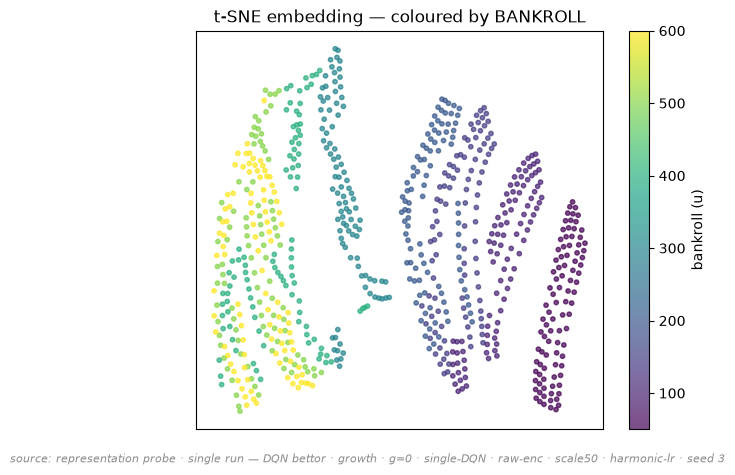

In [2]:
plot_bet_embedding(coords, states.bankroll, "bankroll (u)", "t-SNE embedding — coloured by BANKROLL",
                   note=bet_provenance(probe_run, role="representation probe"))

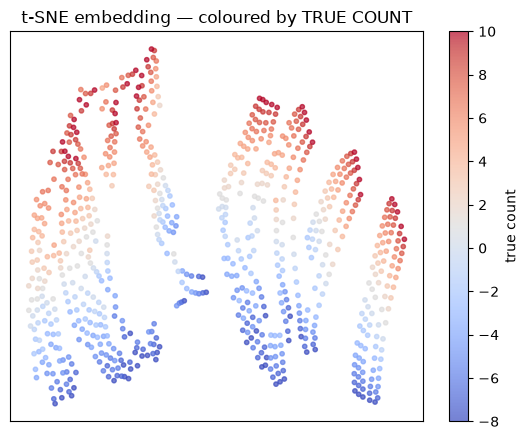

In [3]:
plot_bet_embedding(coords, states.true_count, "true count", "t-SNE embedding — coloured by TRUE COUNT", cmap="coolwarm")

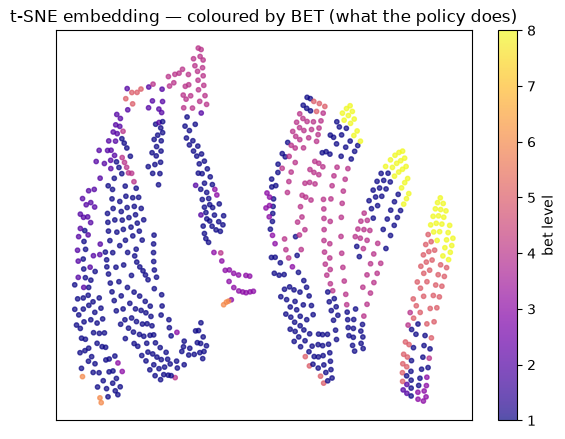

In [4]:
plot_bet_embedding(coords, bet, "bet level", "t-SNE embedding — coloured by BET (what the policy does)", cmap="plasma")

Three colourings, three tempting stories. **Bankroll** separates the clusters — *"it keyed on wealth."*
**Count** is a clean gradient within each cluster — *"no, it encoded the count."* And the **bet** panel
seems to settle it: the wager rising with count on the low-bankroll (right) side — *"so it sizes on the
count."* Three confident reads from one picture, each with a story. Before believing any of them, we asked
the only question that matters for an embedding: **does it replicate?**

## 4.2 The over-read we caught — none of the three replicate

Two disciplines dissolved all three reads. First, **out-of-distribution**: the grid sweeps bankroll
**50–600u**, but the agents *live* at ~400u — most of that wealth axis is states the policy never occupies,
so the clean bankroll separation is largely the network extrapolating over wealth it was never evaluated at.

Second, and decisive: **replication.** If any of the structure were a real property of the policy, it would
hold across training seeds. So we probed *every* seed's bet-vs-count — at the native bankroll, and at a low,
out-of-distribution one — with discrete-Kelly dashed for reference:

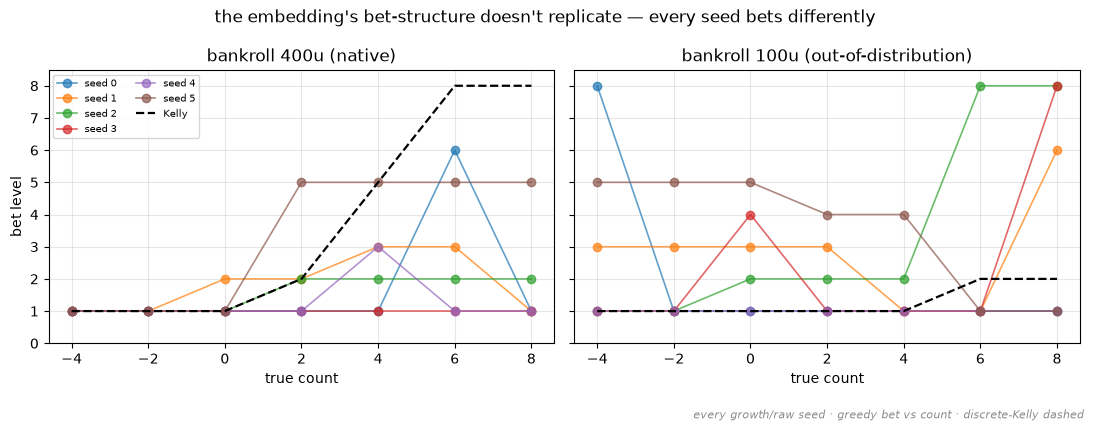

In [5]:
plot_bet_replication("growth", "raw", bankrolls=(400, 100),
                     note="every growth/raw seed · greedy bet vs count · discrete-Kelly dashed")

The reads don't survive. At the **native** 400u the seeds range from dead-flat (seed 3 — the one the
embedding above came from) through coarse gating (seed 5) to erratic (seed 0), and *none* is the Kelly ramp.
Off-distribution the disagreement is worse: some seeds rise with count, some fall, some saturate — all of
them wildly over-betting the (nearly flat) low-bankroll Kelly. The clean structure in that single embedding
was **one seed's idiosyncrasy**, not a policy. An embedding is *suggestive, not decisive* — which is exactly
why the next step stops interpreting pictures and runs a controlled experiment.

## 4.3 The controlled test — remove wealth entirely

An embedding is suggestive, not decisive, and we had just been burned reading one. So we ran the
controlled experiment. The bet encoder was made configurable — `--bankroll-feature`:

- **`raw`** — the original: bankroll fed to the network as-is,
- **`logratio`** — bankroll as `log(current / start)`, a scale-free wealth signal,
- **`none`** — **bankroll removed from the input entirely.**

If the agent keyed on wealth, `none` should behave *differently* — it can no longer see wealth at all. This
turns "it keyed on wealth" from an interpretation of a picture into a prediction we can test.

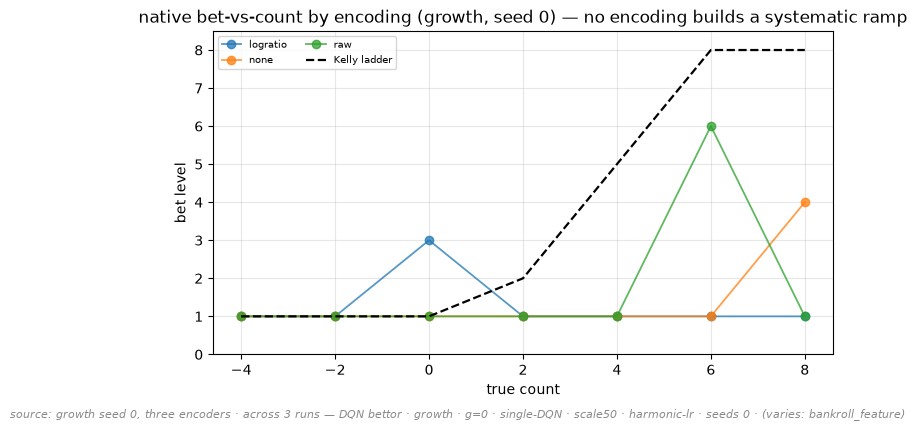

In [6]:
seed0 = runs[(runs.regime == "growth") & (runs.seed == 0)].groupby("bankroll_feature", as_index=False).tail(1)
plot_native_curves(seed0.sort_values("bankroll_feature"), label=lambda r: r.bankroll_feature,
                   title="native bet-vs-count by encoding (growth, seed 0) — no encoding builds a systematic ramp",
                   note=bet_provenance(seed0, role="growth seed 0, three encoders"))

## 4.4 Falsified — the encoding doesn't matter

The four-axis growth, across seeds, for all three encoders against the baselines. **`none` is
statistically identical to `raw`** (−0.19 ± 0.04 vs −0.19 ± 0.08 ×10⁻⁴), and `logratio` is no better. All
three sit at **≈ Flat**. Removing wealth from the input changes *nothing*.

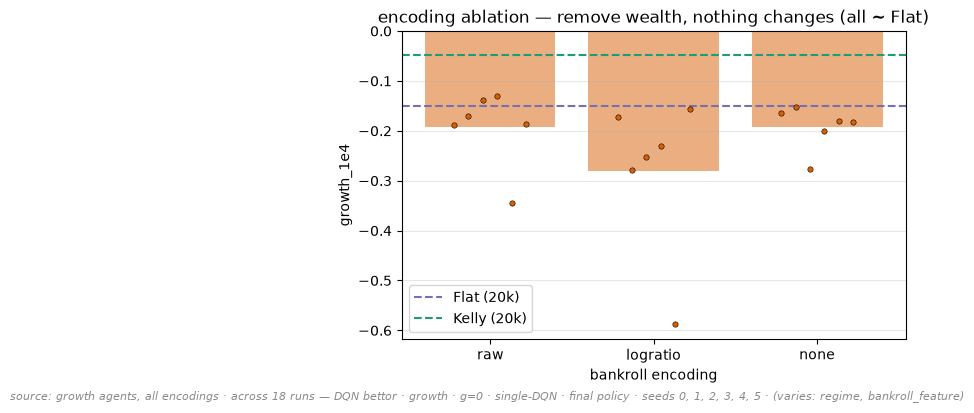

In [7]:
plot_encoding_ablation(evals, note=bet_provenance(evals[(evals.train_regime=='growth')&(evals.bettor=='agent')&(evals.phase=='final')], role="growth agents, all encodings"))

## 4.5 What this closes

The hypothesis is falsified. If the failure were the agent *spending its capacity on wealth*, deleting the
wealth input would have freed that capacity to find the count ramp — and it did not. The agent that cannot
see its bankroll at all still bets ≈ Flat. So the wall is not the representation; it is the **thin,
sub-noise edge of Chapter 3**. No encoding change reaches it.

The arc matters as much as the result: we formed a hypothesis, found apparent support in an embedding,
**caught our own over-reading** — the structure was out-of-distribution *and* didn't replicate across
seeds — and then built a controlled ablation that settled it against us. That is the evaluator's job —
including being willing to falsify your own idea. Chapter 5 draws the threads together.